# A09 — Deutsch–Jozsa and Bernstein–Vazirani

**Track A — under the hood.** Pure NumPy. Qiskit is not imported anywhere in this
notebook; every oracle here is a matrix we build ourselves, entry by entry.

---

## The one-sentence version

You are handed a black box that computes some function $f$ of an $n$-bit input.
Classically you can only ask it *"what is $f$ of this particular input?"* — one
input at a time. A quantum computer can ask it **one question about all
$2^n$ inputs at once**, and arrange for the useless parts of the answer to cancel.

## The idea, before any algebra

Imagine a box that takes a 4-bit number and returns a single bit. Someone
promises you the box is one of exactly two kinds:

- **constant** — it returns the same bit for all 16 inputs, or
- **balanced** — it returns 0 for exactly 8 inputs and 1 for the other 8.

Which kind is it? Classically you poke it. One answer tells you nothing. Two
different answers prove it is balanced. But if the first nine answers all agree,
you are *still not certain* — a balanced function could have handed you its eight
0s first and be about to hand you a 1. To be **certain**, in the worst case, you
need $2^{n-1}+1 = 9$ queries.

The quantum trick is not "try all inputs in parallel and read them all off". You
cannot read them all off; one measurement gives you one answer. The trick is:

1. Put the input register in a superposition of **all** $2^n$ inputs at once.
2. Ask the box once. Every input picks up its own answer — as a **sign**, not as
   a readable bit.
3. Interfere the whole thing back together. Arrange it so that the eight $+$
   signs and eight $-$ signs of a balanced function **destroy each other** at the
   all-zeros outcome, while a constant function's signs all **agree** and pile up
   there.

Then measure. If you see $|0000\rangle$, the box was constant. If you see
anything else, it was balanced. One query, no error, no repetition.

That is Deutsch–Jozsa. **Bernstein–Vazirani** is the same machinery pointed at a
different question: the box computes $f(x) = s\cdot x \bmod 2$ for a hidden
$n$-bit secret $s$, and one query hands you all $n$ bits of $s$ at once instead
of the $n$ queries you would need classically.

## What is actually doing the work

Nothing here is "parallelism". Superposition gets $2^n$ signs into the register;
**interference** is what turns those signs into a single readable answer. If you
take one thing from this notebook, take the filmstrip in Figure 2: the bar heights
do not change when the oracle runs — only the colours do — and then the final
Hadamard layer converts colour into height. Phase in, probability out.

## Honest warning, up front

This is the notebook where most tutorials quietly lie. They show
"$2^{n-1}+1$ classical queries versus 1 quantum query" and call it an exponential
speedup. It is exponential only under a *worst-case, zero-error, promised* reading
of the problem. Allow the classical algorithm to be **randomized** and to be wrong
one time in a million and it needs about **20 queries — for any $n$**. Figure 6
draws that honestly. Read it before you quote this algorithm at anyone.

In [1]:
from qviz import backends, grid, style

import matplotlib.pyplot as plt
import numpy as np

style.use()

SEED = backends.seed_for("A09")
rng = np.random.default_rng(SEED)
print("seed:", SEED)

seed: 20260813


## Step 0 — pin down which bit is which

Oracle code is where endianness bugs go to hide. A phase oracle is a diagonal
matrix, and a diagonal matrix with the bits read backwards is still a perfectly
valid diagonal matrix — it just answers a different question, silently. So we fix
the convention first and then assert it.

**The repo convention (little-endian, matching Qiskit).** Basis state index $i$
of an $n$-qubit register corresponds to the bitstring in which **qubit 0 is the
rightmost character**:

$$\text{bit } q \text{ of } i \;=\; (i \gg q)\ \&\ 1.$$

The useful consequence for this notebook: an integer input $x$ to our function
*is* the basis-state index. `f(5)` on 4 bits means $f$ applied to the input
$x_3x_2x_1x_0 = 0101$, i.e. qubit 0 and qubit 2 set. We never have to reverse a
string anywhere — provided we are consistent about it, which the assertion below
checks.

In [2]:
I2 = np.eye(2, dtype=complex)
X = np.array([[0, 1], [1, 0]], dtype=complex)
Z = np.array([[1, 0], [0, -1]], dtype=complex)
H = np.array([[1, 1], [1, -1]], dtype=complex) / np.sqrt(2)


def op_on(U, k, n):
    """Place single-qubit U on qubit k of an n-qubit register (little-endian).

    Qubit 0 is the RIGHTMOST label character, hence the LAST Kronecker factor,
    so the loop runs from qubit n-1 down to qubit 0.
    """
    out = np.array([[1.0 + 0j]])
    for j in range(n - 1, -1, -1):
        out = np.kron(out, U if j == k else I2)
    return out


def label(i, n):
    """Printed bitstring for basis index i: qubit n-1 leftmost, qubit 0 rightmost."""
    return format(i, f"0{n}b")


def bit(x, q):
    """Bit q of integer x, little-endian."""
    return (x >> q) & 1


def parity(v):
    """Parity of the popcount: 1 if v has an odd number of set bits."""
    return bin(v).count("1") & 1


# The convention, asserted rather than assumed.
v = np.zeros(8, dtype=complex); v[0] = 1.0
moved = int(np.argmax(np.abs(op_on(X, 0, 3) @ v)))
print("X on qubit 0 of |000> -> index", moved, "=", "|" + label(moved, 3) + ">")
assert moved == 1, "endianness broken: qubit 0 must be the rightmost bit"

for x in (5, 6):
    print(f"x = {x:2d}  label |{label(x, 4)}>   "
          f"bits (q0..q3) = {[bit(x, q) for q in range(4)]}")

X on qubit 0 of |000> -> index 1 = |001>
x =  5  label |0101>   bits (q0..q3) = [1, 0, 1, 0]
x =  6  label |0110>   bits (q0..q3) = [0, 1, 1, 0]


## Step 1 — what an oracle actually is

A quantum "black box" cannot be an arbitrary function. It has to be **unitary**,
which means reversible, and $x \mapsto f(x)$ is not reversible when $f$ throws
information away. The standard fix is to keep the input and XOR the answer onto
an extra **ancilla** qubit:

$$U_f\,|x\rangle_{\text{in}} |y\rangle_{\text{anc}} \;=\; |x\rangle\,|y \oplus f(x)\rangle.$$

That is a permutation of basis states — it is its own inverse, so it is certainly
unitary — and it works for *any* $f$, at the cost of one extra qubit.

We put the ancilla on **qubit $n$**, the highest index, so it is the leftmost
character of the printed label and `np.kron(ancilla, input)` builds the joint
state correctly.

### The move that makes everything work: phase kickback

Prepare the ancilla in $|-\rangle = \tfrac{1}{\sqrt2}(|0\rangle - |1\rangle)$
instead of $|0\rangle$. Then

$$|y \oplus f(x)\rangle \text{ summed against } |-\rangle
\;=\; \tfrac{1}{\sqrt2}\big(|0 \oplus f(x)\rangle - |1 \oplus f(x)\rangle\big)
\;=\; (-1)^{f(x)}\,|-\rangle,$$

because XOR-ing 1 into the ancilla just swaps the two terms of $|-\rangle$, which
is the same as multiplying by $-1$. So

$$U_f\big(|x\rangle \otimes |-\rangle\big) = (-1)^{f(x)}\,|x\rangle \otimes |-\rangle.$$

The ancilla **never changes**. The answer comes back as a sign on the input
register — this is the *phase kickback* A08 introduced, and it is why the ancilla
can be dropped from every picture in this notebook. From here on we work with the
equivalent **phase oracle** on $n$ qubits alone:

$$D_f = \mathrm{diag}\big((-1)^{f(0)},\,(-1)^{f(1)},\,\ldots,\,(-1)^{f(2^n-1)}\big).$$

We build both and check they agree, because the $n+1$-qubit version is the one a
real machine runs and the $n$-qubit version is the one we can draw.

In [3]:
def phase_oracle(f, n):
    """D_f = diag((-1)^f(x)). Acts on the n input qubits alone."""
    return np.diag([(-1.0) ** f(x) for x in range(2 ** n)]).astype(complex)


def xor_oracle(f, n):
    """U_f |x>|y> = |x>|y xor f(x)>, ancilla on qubit n (the leftmost label bit).

    Basis index i of the (n+1)-qubit register splits as
        x = i & (2**n - 1)        the input register, qubits 0..n-1
        y = (i >> n) & 1          the ancilla,       qubit n
    """
    dim = 2 ** (n + 1)
    M = np.zeros((dim, dim), dtype=complex)
    for i in range(dim):
        x, y = i & (2 ** n - 1), (i >> n) & 1
        j = x | ((y ^ f(x)) << n)
        M[j, i] = 1.0            # column i lands on row j
    return M


def hadamard_all(n):
    """H on every qubit. All factors are equal, so ordering cannot bite here."""
    out = np.array([[1.0 + 0j]])
    for _ in range(n):
        out = np.kron(out, H)
    return out


MINUS = np.array([1, -1], dtype=complex) / np.sqrt(2)

# --- phase kickback, verified as a matrix identity, not asserted by hand ------
n_demo = 3
f_demo = lambda x: (x * x + 1) % 2          # some arbitrary function
Uf = xor_oracle(f_demo, n_demo)
Df = phase_oracle(f_demo, n_demo)

# np.kron(ancilla, input): the ancilla is the HIGHEST qubit, so it is the FIRST
# Kronecker factor. Getting this backwards is the classic bug.
for _ in range(5):
    psi = rng.normal(size=2 ** n_demo) + 1j * rng.normal(size=2 ** n_demo)
    psi /= np.linalg.norm(psi)
    lhs = Uf @ np.kron(MINUS, psi)
    rhs = np.kron(MINUS, Df @ psi)
    assert np.allclose(lhs, rhs)

print("U_f is unitary          :", np.allclose(Uf.conj().T @ Uf, np.eye(2 ** (n_demo + 1))))
print("U_f is its own inverse  :", np.allclose(Uf @ Uf, np.eye(2 ** (n_demo + 1))))
print("kickback identity holds :  U_f (|x> (x) |->) == (-1)^f(x) |x> (x) |->")
print("\nthe ancilla really is untouched:")
out = Uf @ np.kron(MINUS, np.ones(2 ** n_demo, dtype=complex) / np.sqrt(2 ** n_demo))
anc = out.reshape(2, 2 ** n_demo)              # rows = ancilla value
print("  ancilla component |0> norm:", f"{np.linalg.norm(anc[0]):.6f}")
print("  ancilla component |1> norm:", f"{np.linalg.norm(anc[1]):.6f}")
print("  ratio -> still exactly |->  :",
      np.allclose(anc[1], -anc[0]))

U_f is unitary          : True
U_f is its own inverse  : True
kickback identity holds :  U_f (|x> (x) |->) == (-1)^f(x) |x> (x) |->

the ancilla really is untouched:
  ancilla component |0> norm: 0.707107
  ancilla component |1> norm: 0.707107
  ratio -> still exactly |->  : True


Both norms are $1/\sqrt2$ and the $|1\rangle$ component is exactly minus the
$|0\rangle$ component: the ancilla came out in $|-\rangle$, unchanged, having done
its job. It is a catalyst.

That is worth pausing on, because it is the reason "quantum parallelism" is a bad
name for this. The oracle *did* evaluate $f$ on all eight inputs. It wrote all
eight answers into the state. And the register that was supposed to receive them
is bit-for-bit identical to how it started. The answers are in the **relative
phases** of the input register, where no measurement can read them directly.
Getting them out is a separate problem, and it is the whole problem.

## Figure 1 — an oracle *is* a sign pattern

Since the ancilla drops out, an oracle for our purposes is nothing more than a
$\pm1$ label on each of the $2^n$ inputs. So draw it that way: 16 cells, one per
4-bit input, coloured by sign — pulling the two colours straight off the repo's
phase wheel, so "$+1$" here is the same warm hue that phase $0$ gets in every
amplitude-bar plot, and "$-1$" is the teal of phase $\pi$. A sign *is* a phase.

The 16 inputs are laid out on a $4\times4$ grid: **rows are the two high bits
$q_3q_2$, columns are the two low bits $q_1q_0$**. That layout is chosen so the
endianness is visible — the oracle $f(x) = x_0$ must come out striped
*vertically*, because it depends only on the fastest-varying (rightmost) bit.

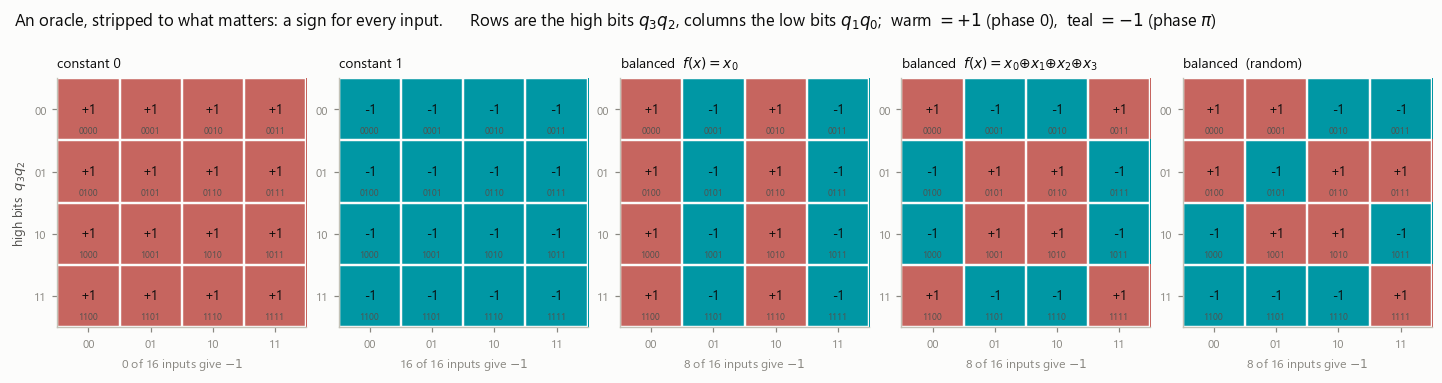

sum of signs over all 16 inputs (this is what the algorithm measures):
  constant 0                         constant  sum = +16   sum/16 = +1.000
  constant 1                         constant  sum = -16   sum/16 = -1.000
  balanced  f(x)=x_0                 balanced  sum =  +0   sum/16 = +0.000
  balanced  f(x)=x_0+x_1+x_2+x_3     balanced  sum =  +0   sum/16 = +0.000
  balanced  (random)                 balanced  sum =  +0   sum/16 = +0.000


In [4]:
from matplotlib.colors import ListedColormap

N_BITS = 4
N_IN = 2 ** N_BITS

# The two ends of the repo's phase map: sign +1 is phase 0, sign -1 is phase pi.
SIGN_CMAP = ListedColormap([style.PHASE(0.0), style.PHASE(0.5)])


def sign_grid(f, n=N_BITS):
    """f as a 4x4 image: row = high two bits, col = low two bits."""
    return np.array([[f((r << 2) | c) for c in range(4)] for r in range(4)])


rand_bal_mask = np.zeros(N_IN, dtype=int)
rand_bal_mask[rng.permutation(N_IN)[:N_IN // 2]] = 1
f_rand_balanced = lambda x: int(rand_bal_mask[x])

ORACLES = [
    ("constant 0", lambda x: 0, "constant"),
    ("constant 1", lambda x: 1, "constant"),
    (r"balanced  $f(x)=x_0$", lambda x: bit(x, 0), "balanced"),
    (r"balanced  $f(x)=x_0{\oplus}x_1{\oplus}x_2{\oplus}x_3$", parity, "balanced"),
    ("balanced  (random)", f_rand_balanced, "balanced"),
]

fig, axes = plt.subplots(1, 5, figsize=(13.0, 3.35))
for ax, (name, f, kind) in zip(axes, ORACLES):
    G = sign_grid(f)
    ax.imshow(G, cmap=SIGN_CMAP, vmin=0, vmax=1, interpolation="nearest")
    for r in range(4):
        for c in range(4):
            x = (r << 2) | c
            ax.text(c, r, "+1" if G[r, c] == 0 else "-1", ha="center",
                    va="center", fontsize=8.5, color=style.INK)
            ax.text(c, r + 0.34, label(x, 4), ha="center", va="center",
                    fontsize=6.0, color=style.INK_2)
    ax.set_xticks(range(4)); ax.set_yticks(range(4))
    ax.set_xticklabels(["00", "01", "10", "11"], fontsize=7.5)
    ax.set_yticklabels(["00", "01", "10", "11"], fontsize=7.5)
    ax.set_xticks(np.arange(-0.5, 4, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, 4, 1), minor=True)
    ax.grid(which="minor", color=style.SURFACE, linewidth=1.6)
    ax.grid(which="major", visible=False)
    ax.tick_params(which="minor", length=0)
    n_minus = int(G.sum())
    ax.set_title(name, loc="left", fontsize=9, pad=7)
    ax.set_xlabel(f"{n_minus} of 16 inputs give $-1$", fontsize=8,
                  color=style.MUTED)

axes[0].set_ylabel("high bits  $q_3q_2$", fontsize=8.5)
fig.suptitle("An oracle, stripped to what matters: a sign for every input."
             "      Rows are the high bits $q_3q_2$, columns the low bits "
             "$q_1q_0$;  warm $= +1$ (phase 0),  teal $= -1$ (phase $\\pi$)",
             x=0.005, ha="left", fontsize=11)
plt.show()

print("sum of signs over all 16 inputs (this is what the algorithm measures):")
for name, f, kind in ORACLES:
    s = sum((-1) ** f(x) for x in range(N_IN))
    plain = name.replace("$", "").replace("\\oplus", "+").replace("{", "").replace("}", "")
    print(f"  {plain:<34} {kind:<8}  sum = {s:+3d}   sum/16 = {s/16:+.3f}")

The last printout is the entire algorithm in one number.

The amplitude Deutsch–Jozsa leaves on the all-zeros outcome is exactly
$\frac{1}{2^n}\sum_x (-1)^{f(x)}$ — the **average sign**. Constant means every
term agrees, so the average is $\pm1$ and *all* the probability lands on
$|0000\rangle$. Balanced means the terms cancel in perfectly matched pairs, so
the average is $0$ and *none* of it does. There is no approximation and no
statistics: the two cases are $1$ and $0$, exactly.

Notice also that $f(x)=x_0$ came out striped vertically and the parity oracle came
out as a checkerboard. Had we written the bits the other way round, the first
panel would be striped *horizontally* — same picture, wrong question.

## Figure 2 — the filmstrip

Here is the whole of Deutsch–Jozsa, one column per stage, for three qubits
(eight inputs):

$$|000\rangle
\;\xrightarrow{\;H^{\otimes3}\;}\;
\frac{1}{\sqrt8}\sum_x |x\rangle
\;\xrightarrow{\;D_f\;}\;
\frac{1}{\sqrt8}\sum_x (-1)^{f(x)}|x\rangle
\;\xrightarrow{\;H^{\otimes3}\;}\;
\sum_y \Big(\tfrac{1}{8}\sum_x (-1)^{f(x)+x\cdot y}\Big)|y\rangle.$$

The top row is a constant oracle, the bottom row a balanced one. The **only**
difference between the two runs is the sign pattern in column 3. Watch three
things:

1. **Column 2 is identical in both rows.** Eight equal bars, all phase 0. The
   register knows nothing yet.
2. **Column 3 changes no bar heights.** The oracle is a diagonal of $\pm1$; it
   cannot move probability, only recolour it. If you measured here you would get
   a uniform random 3-bit string in both cases and learn nothing at all. Every
   bit of the answer is sitting in the colours.
3. **Column 4 is where the physics happens.** The final Hadamard layer takes each
   output $y$ and adds up all eight amplitudes with signs $(-1)^{x\cdot y}$. For
   the constant oracle at $y=000$ the eight terms are all $+\tfrac{1}{8}$ and sum
   to 1. For the balanced oracle they are four $+$ and four $-$ and sum to
   **exactly zero** — and the leftover amplitude is pushed out to other outcomes.

Column 5 is what you would actually see: probabilities. One shot is enough,
because both distributions are deterministic.

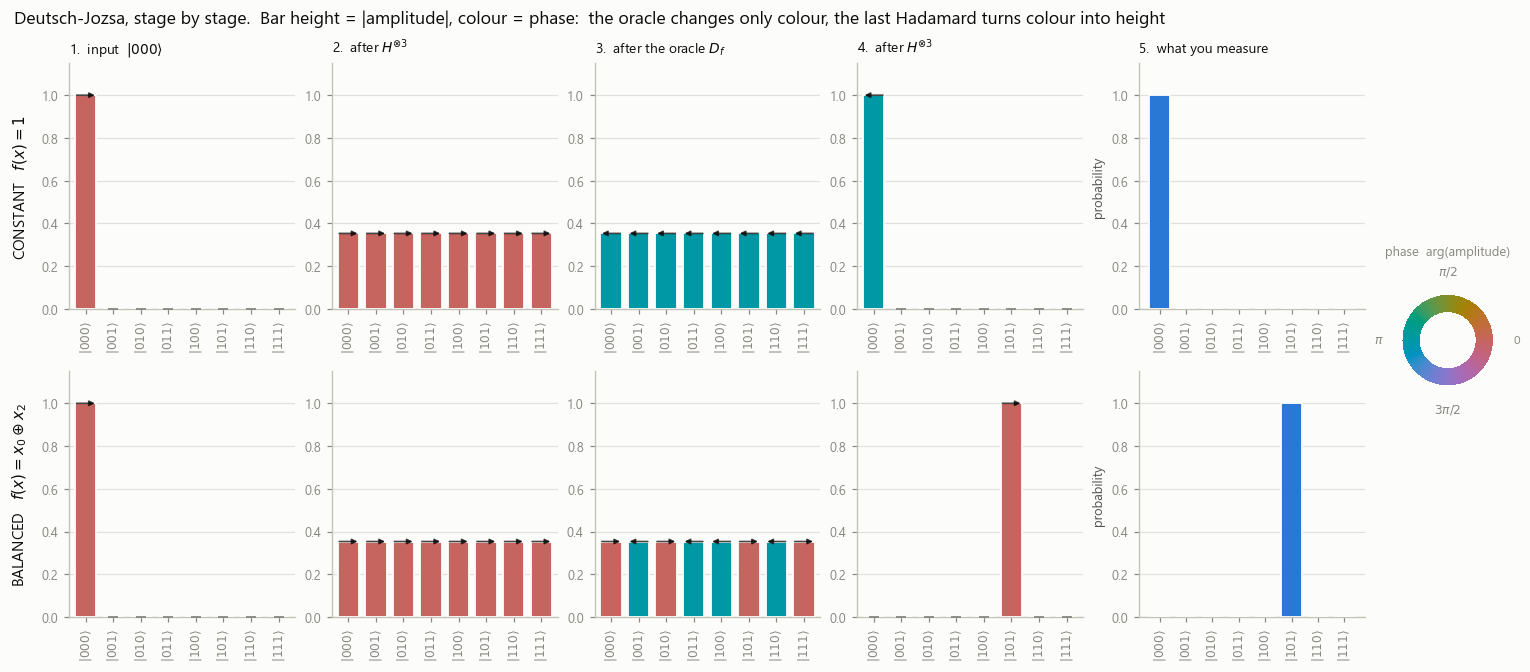

CONSTANT   amplitude on |000> = -1.000000000000000   P(|000>) = 0.999999999999999
BALANCED   amplitude on |000> = +0.000000000000000   P(|000>) = 0.000000000000000


In [5]:
N_DJ = 3
DIM_DJ = 2 ** N_DJ
H_DJ = hadamard_all(N_DJ)


def dj_stages(f, n):
    """The four statevectors of a Deutsch-Jozsa run, n input qubits."""
    Hn = hadamard_all(n)
    v0 = np.zeros(2 ** n, dtype=complex); v0[0] = 1.0
    v1 = Hn @ v0                       # uniform superposition
    v2 = phase_oracle(f, n) @ v1       # oracle writes the signs
    v3 = Hn @ v2                       # interference
    return [v0, v1, v2, v3]


f_const = lambda x: 1                              # constant 1
f_bal = lambda x: bit(x, 0) ^ bit(x, 2)            # balanced

runs = [("CONSTANT   $f(x) = 1$", f_const), ("BALANCED   $f(x) = x_0 \\oplus x_2$", f_bal)]
stage_titles = [r"1.  input  $|000\rangle$", r"2.  after $H^{\otimes 3}$",
                r"3.  after the oracle $D_f$", r"4.  after $H^{\otimes 3}$",
                "5.  what you measure"]

fig = plt.figure(figsize=(13.8, 6.0))
gs = fig.add_gridspec(2, 6, width_ratios=[1, 1, 1, 1, 1, 0.42])

for r, (rname, f) in enumerate(runs):
    stages = dj_stages(f, N_DJ)
    for c, vec in enumerate(stages):
        ax = fig.add_subplot(gs[r, c])
        grid.amp_bars(ax, vec, ylim=1.15, label_rotation=90)
        ax.set_ylabel(rname if c == 0 else "", fontsize=10, color=style.INK,
                      labelpad=8)
        if r == 0:
            ax.set_title(stage_titles[c], loc="left", fontsize=9, pad=7)
    axp = fig.add_subplot(gs[r, 4])
    grid.prob_bars(axp, np.abs(stages[3]) ** 2, ymax_pad=1.18,
                   label_rotation=90)
    axp.set_ylim(0, 1.15)
    axp.set_ylabel("probability", fontsize=8.5)
    if r == 0:
        axp.set_title(stage_titles[4], loc="left", fontsize=9, pad=7)

axw = fig.add_subplot(gs[:, 5], projection="polar")
style.phase_wheel(axw)

fig.suptitle("Deutsch-Jozsa, stage by stage.  Bar height = |amplitude|, colour = "
             "phase:  the oracle changes only colour, the last Hadamard turns "
             "colour into height", x=0.005, ha="left", fontsize=11.5)
plt.show()

for rname, f in runs:
    v = dj_stages(f, N_DJ)[3]
    plain = rname.split()[0]
    print(f"{plain:<9}  amplitude on |000> = {v[0].real:+.15f}"
          f"   P(|000>) = {abs(v[0])**2:.15f}")

Read the bottom row's column 3 against column 4 once more. Four bars turned
red, nothing moved, and the entire eight-bar distribution collapsed onto two
outcomes. Nothing was "tried in parallel and looked up". Eight amplitudes were
added together with signs, and four of them killed the other four.

The decision rule is embarrassingly simple: **measure; if the result is all
zeros, the function was constant, otherwise it was balanced.** It is right every
time, with one query, and it is never right "with high probability" — the
probabilities are exactly 1 and exactly 0.

Which basis state a balanced function lands on is not arbitrary either. For
$f(x) = x_0 \oplus x_2$ everything lands on $|101\rangle$ — the mask of which
bits $f$ actually depends on. That is not a coincidence, and it is the whole of
Bernstein–Vazirani; we get to it below.

## Figure 3 — every function on three bits, not just the convenient ones

The claim so far was made for two hand-picked oracles. Let us check it against
**all of them**, and then break it on purpose.

There are $\binom{8}{4} = 70$ balanced functions on three bits and 2 constant
ones. The left panel runs Deutsch–Jozsa on each of the 72 and shows the resulting
output distribution as a row. Dark means high probability. The first column — the
$|000\rangle$ outcome — is full-strength dark for the two constants and *the
palest possible shade for all 70 balanced ones*. Not nearly empty: empty. The
middle panel plots the same column as numbers.

The right panel is the honest one. There are $2^8 = 256$ functions from three
bits to one bit, and only 72 of them satisfy the promise. Run the algorithm on
all 256 and $P(|000\rangle)$ takes **every value of the form $(k/4 - 1)^2$**,
$k = 0\ldots8$. A function that returns 1 on five inputs out of eight gives
$P = 0.0625$ — small, but not zero, and one shot cannot distinguish "small" from
"zero".

So the promise is not decoration. Without it, a single measurement of $|000\rangle$
does not mean "constant"; it means "the average sign was large", and the algorithm
has no way to tell you which.

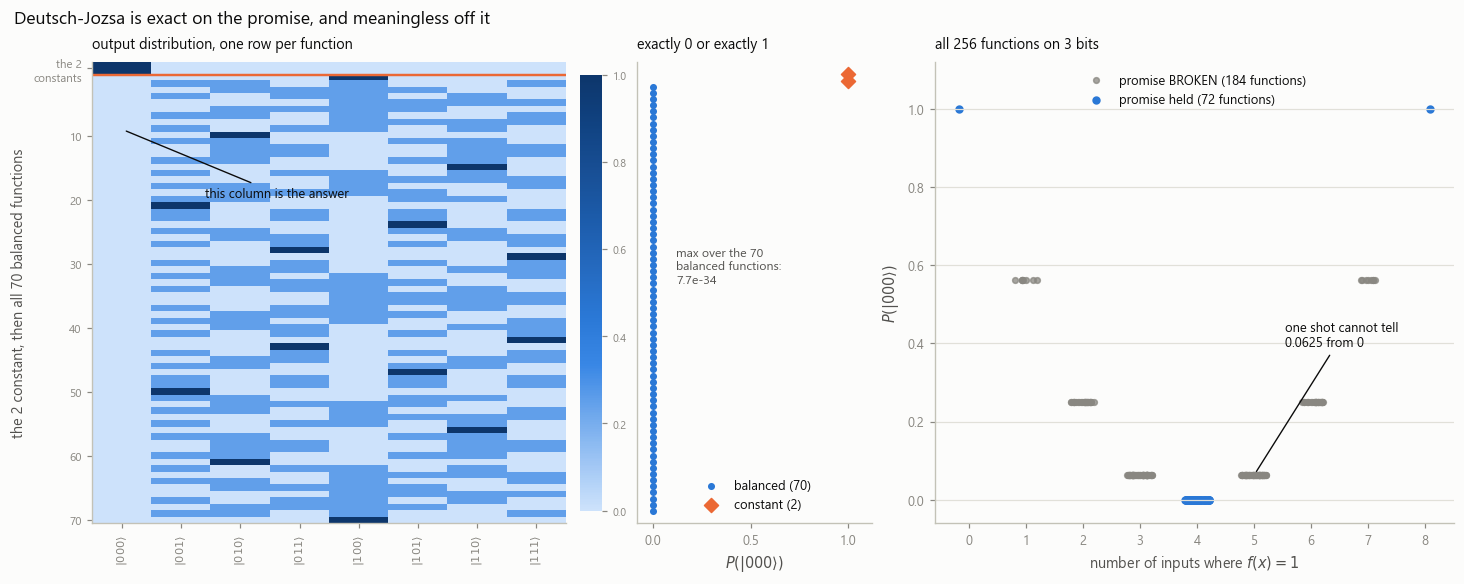

P(|000>) over the 70 balanced functions:  max = 7.704e-34  (that is float noise, not physics)
P(|000>) over the 2 constant functions :  min = 0.999999999999999
distinct P(|000>) values over all 256 functions: [0.     0.0625 0.25   0.5625 1.    ]


In [6]:
from itertools import combinations


def f_from_mask(mask):
    """Build f from a length-8 array of 0/1 values."""
    return lambda x, m=mask: int(m[x])


const_masks = [np.zeros(DIM_DJ, dtype=int), np.ones(DIM_DJ, dtype=int)]
balanced_masks = []
for ones in combinations(range(DIM_DJ), DIM_DJ // 2):
    m = np.zeros(DIM_DJ, dtype=int)
    m[list(ones)] = 1
    balanced_masks.append(m)

promised = const_masks + balanced_masks
probs = np.array([np.abs(dj_stages(f_from_mask(m), N_DJ)[3]) ** 2
                  for m in promised])

# All 256 functions, promise or not.
all_masks = [np.array([(k >> b) & 1 for b in range(DIM_DJ)], dtype=int)
             for k in range(2 ** DIM_DJ)]
p0_all = np.array([abs(dj_stages(f_from_mask(m), N_DJ)[3][0]) ** 2
                   for m in all_masks])
n_ones = np.array([int(m.sum()) for m in all_masks])

fig = plt.figure(figsize=(13.2, 5.2))
gs = fig.add_gridspec(1, 3, width_ratios=[1.05, 0.52, 1.15])

ax0 = fig.add_subplot(gs[0, 0])
im = ax0.imshow(probs, cmap=style.SEQ, vmin=0, vmax=1, aspect="auto",
                interpolation="nearest")
ax0.axhline(1.5, color=style.ORANGE, lw=1.6)
ax0.set_xticks(range(DIM_DJ))
ax0.set_xticklabels([grid.ket(label(i, 3)) for i in range(DIM_DJ)],
                    fontsize=7.5, rotation=90)
ax0.set_yticks([0.5, 11, 21, 31, 41, 51, 61, 71])
ax0.set_yticklabels(["the 2\nconstants", "10", "20", "30", "40", "50", "60", "70"],
                    fontsize=7.5)
ax0.set_ylabel("the 2 constant, then all 70 balanced functions")
ax0.grid(False)
cb = fig.colorbar(im, ax=ax0, fraction=0.046, pad=0.03)
cb.outline.set_visible(False)
cb.ax.tick_params(labelsize=7, color=style.MUTED, labelcolor=style.MUTED)
ax0.set_title("output distribution, one row per function", loc="left", fontsize=9.5)
grid.annotate(ax0, "this column is the answer", xy=(0.0, 10.0),
              xytext=(1.4, 20.0), color=style.INK)

ax1 = fig.add_subplot(gs[0, 1])
ax1.scatter(probs[2:, 0], np.arange(2, 72), s=13, color=style.BLUE,
            label="balanced (70)")
ax1.scatter(probs[:2, 0], [0, 1], s=42, color=style.ORANGE, marker="D",
            label="constant (2)")
ax1.set_xlim(-0.08, 1.12)
ax1.set_ylim(73, -2)
ax1.set_xticks([0, 0.5, 1.0])
ax1.set_xlabel(r"$P(|000\rangle)$")
ax1.set_yticks([])
ax1.legend(loc="lower center", ncols=1)
ax1.set_title("exactly 0 or exactly 1", loc="left", fontsize=9.5)
ax1.text(0.12, 34, f"max over the 70\nbalanced functions:\n"
         f"{probs[2:, 0].max():.1e}", fontsize=8, color=style.INK_2)

ax2 = fig.add_subplot(gs[0, 2])
jit = rng.uniform(-0.22, 0.22, size=len(p0_all))
inside = np.isin(n_ones, [0, DIM_DJ, DIM_DJ // 2])
ax2.scatter(n_ones[~inside] + jit[~inside], p0_all[~inside], s=14,
            color=style.MUTED, alpha=0.75, label="promise BROKEN (184 functions)")
ax2.scatter(n_ones[inside] + jit[inside], p0_all[inside], s=20,
            color=style.BLUE, label="promise held (72 functions)")
ax2.set_xticks(range(DIM_DJ + 1))
ax2.set_xlabel("number of inputs where $f(x) = 1$")
ax2.set_ylabel(r"$P(|000\rangle)$")
ax2.set_ylim(-0.06, 1.12)
ax2.legend(loc="upper center", ncols=1)
ax2.set_title("all 256 functions on 3 bits", loc="left", fontsize=9.5)
grid.annotate(ax2, "one shot cannot tell\n0.0625 from 0", xy=(5.0, 0.0625),
              xytext=(5.55, 0.42), color=style.INK)

fig.suptitle("Deutsch-Jozsa is exact on the promise, and meaningless off it",
             x=0.005, ha="left", fontsize=11.5)
plt.show()

print("P(|000>) over the 70 balanced functions:  max =",
      f"{probs[2:, 0].max():.3e}", " (that is float noise, not physics)")
print("P(|000>) over the 2 constant functions :  min =",
      f"{probs[:2, 0].min():.15f}")
print("distinct P(|000>) values over all 256 functions:",
      np.round(np.unique(np.round(p0_all, 12)), 4))

$3\times10^{-33}$ is not a small probability; it is the size of a rounding error
in double precision. The balanced case cancels *identically*, as an algebraic
fact about $\sum_x(-1)^{f(x)}$, and the only reason it is not printed as `0.0` is
that we added eight floats in some particular order.

The right panel is the one to remember. The nine possible values of
$P(|000\rangle)$ are $(k/4-1)^2$ for $k$ inputs mapping to 1 — a parabola through
the promise's two endpoints. Deutsch–Jozsa does not detect "constant"; it
measures **how unbalanced $f$ is**, and the promise is what turns that continuous
quantity into a yes/no answer.

## Bernstein–Vazirani: the same circuit, a better question

Now restrict the oracle to a specific family. A hidden $n$-bit string $s$ is
chosen, and the box computes the bitwise dot product mod 2:

$$f_s(x) \;=\; s\cdot x \;=\; \bigoplus_{q} s_q\,x_q \pmod 2.$$

**Classically this takes exactly $n$ queries** and no fewer: ask $f_s(e_q)$ for
each basis vector $e_q = 2^q$ and read off $s_q$ directly. Each query returns one
bit, and $s$ contains $n$ bits, so $n$ queries is optimal by pure information
counting — there is nothing clever to be done.

**Quantum: one query, always.** Run the exact same circuit as before and the
final amplitude on outcome $y$ is

$$\frac{1}{2^n}\sum_x (-1)^{s\cdot x + x\cdot y}
= \frac{1}{2^n}\sum_x (-1)^{x\cdot(s\oplus y)}
= \begin{cases} 1 & y = s\\ 0 & \text{otherwise,}\end{cases}$$

because summing $(-1)^{x\cdot m}$ over all $x$ gives $2^n$ when $m = 0$ and zero
otherwise — half the terms are $+1$ and half are $-1$ for any non-zero mask $m$.
The final state is *exactly* $|s\rangle$. Measure once and you have the whole
secret.

Note where this fits: $f_s$ is balanced for every $s \neq 0$ and constant for
$s = 0$, so Bernstein–Vazirani's oracles are a subset of Deutsch–Jozsa's. Same
circuit, same one query — we are simply reading the *whole* output register
instead of asking one yes/no question about it.

In [7]:
def bv_oracle_f(s):
    """f_s(x) = s . x mod 2, little-endian bitwise dot product."""
    return lambda x, s=s: parity(s & x)


# The Walsh-Hadamard identity we just used, checked numerically.
for n in range(1, 6):
    Hn = hadamard_all(n)
    want = np.array([[(-1.0) ** parity(x & y) for x in range(2 ** n)]
                     for y in range(2 ** n)]) / np.sqrt(2 ** n)
    assert np.allclose(Hn, want), n
print("H^(x)n [y,x] == (-1)^(x.y) / sqrt(2^n)   verified for n = 1..5")

SECRET = 0b1011
stages = dj_stages(bv_oracle_f(SECRET), N_BITS)
recovered = int(np.argmax(np.abs(stages[3]) ** 2))
print(f"\nsecret    = |{label(SECRET, 4)}>")
print(f"recovered = |{label(recovered, 4)}>   with probability "
      f"{np.abs(stages[3][recovered])**2:.15f}")
print("\nfinal state:", grid.show_state(stages[3]), sep="\n")

H^(x)n [y,x] == (-1)^(x.y) / sqrt(2^n)   verified for n = 1..5

secret    = |1011>
recovered = |1011>   with probability 0.999999999999999

final state:
  |1011>  +1.0000+0.0000j


## Figure 4 — Bernstein–Vazirani, one secret, four stages

Same filmstrip as Figure 2, now on four qubits with $s = 1011$. Sixteen
amplitudes.

The middle panel is the one to stare at. All sixteen bars are the same height —
the oracle has written the secret into the register and the register looks
*completely uniform*. Every bit of information about $s$ is in the pattern of
blue and red. Measure there and you get a uniformly random 4-bit string, sixteen
times out of sixteen useless.

Then one Hadamard layer, and all of it lands on a single bar.

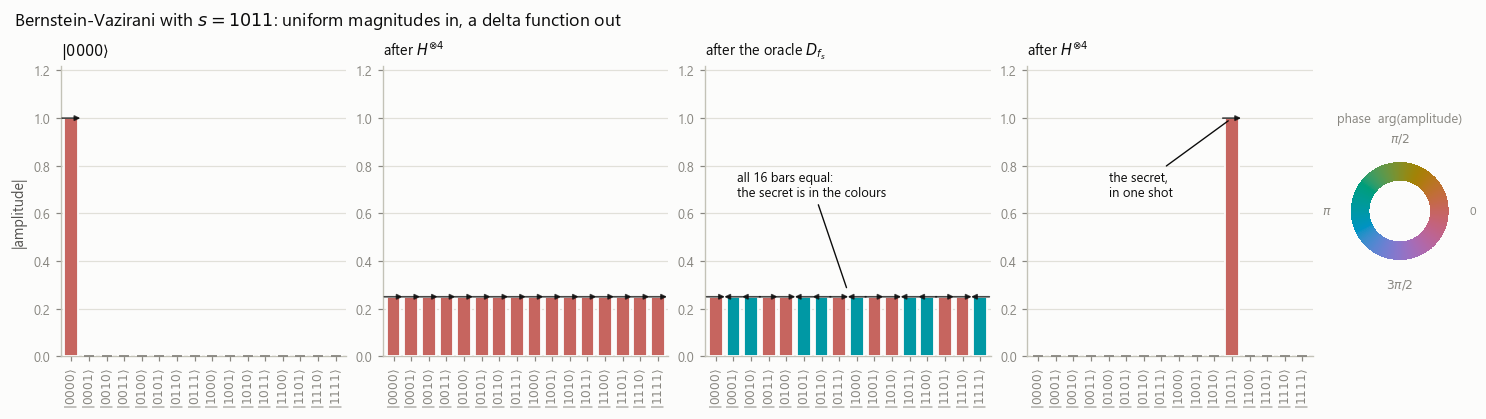

amplitude on the secret: +0.999999999999999
largest other amplitude : 2.776e-17


In [8]:
titles = [r"$|0000\rangle$", r"after $H^{\otimes 4}$",
          r"after the oracle $D_{f_s}$", r"after $H^{\otimes 4}$"]

fig = plt.figure(figsize=(13.4, 3.7))
gs = fig.add_gridspec(1, 5, width_ratios=[1, 1, 1, 1, 0.36])
for c, (vec, t) in enumerate(zip(stages, titles)):
    ax = fig.add_subplot(gs[0, c])
    grid.amp_bars(ax, vec, ylim=1.22, label_rotation=90)
    ax.set_title(t, loc="left", fontsize=9.5, pad=7)
    if c:
        ax.set_ylabel("")
grid.annotate(fig.axes[2], "all 16 bars equal:\nthe secret is in the colours",
              xy=(7.5, 0.27), xytext=(1.2, 0.72), color=style.INK)
grid.annotate(fig.axes[3], "the secret,\nin one shot", xy=(SECRET, 1.0),
              xytext=(4.0, 0.72), color=style.INK)

axw = fig.add_subplot(gs[0, 4], projection="polar")
style.phase_wheel(axw)
fig.suptitle(r"Bernstein-Vazirani with $s = 1011$: uniform magnitudes in, "
             "a delta function out", x=0.005, ha="left", fontsize=11.5)
plt.show()

print("amplitude on the secret:", f"{stages[3][SECRET].real:+.15f}")
print("largest other amplitude :", f"{np.max(np.abs(np.delete(stages[3], SECRET))):.3e}")

## Figure 5 — all sixteen secrets, recovered, as one picture

There are 16 possible 4-bit secrets. Run the algorithm once for each — sixteen
oracle queries in total, one per secret, never two for the same secret — and
stack the recovered bitstrings into an image.

Left: the true secrets, one row each, drawn as bits. Middle: what a single
measurement of the final state returned. Right: their XOR, which is the error,
and which is blank. Far right: the full $16\times16$ matrix of
$P(\text{outcome} \mid \text{secret})$ — a perfect identity, every diagonal entry
exactly 1.

There is no averaging here and no shot noise. A single sample from each of the
sixteen final states reconstructs all sixteen secrets, because each of those
states is a basis state.

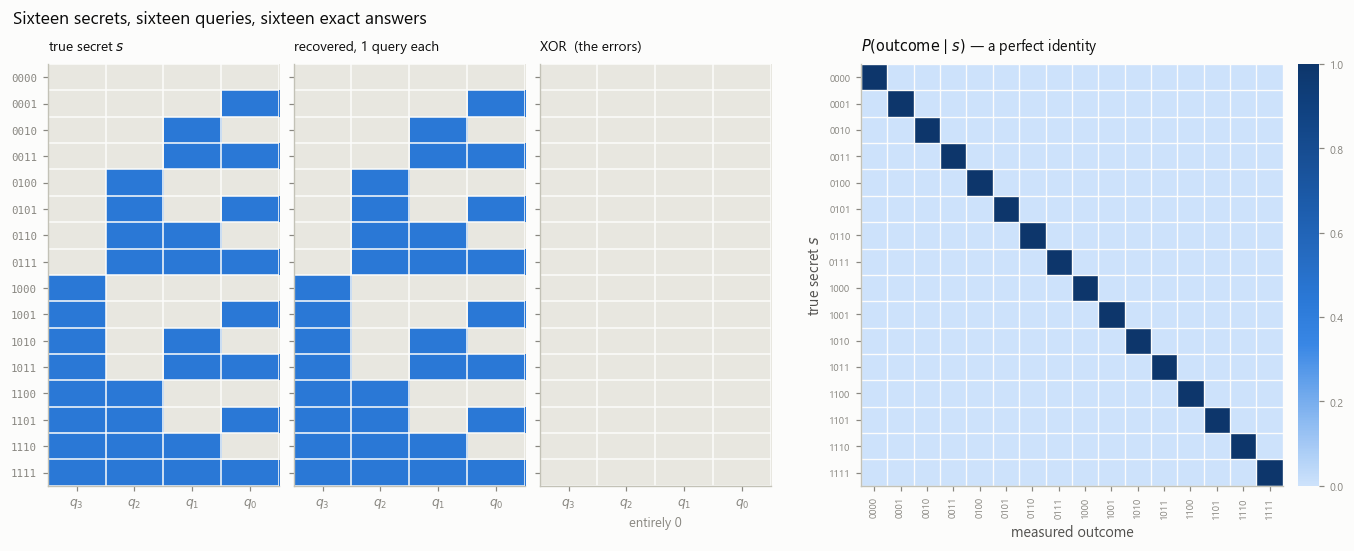

all 16 secrets recovered exactly? True
smallest diagonal probability     : 0.999999999999999
largest off-diagonal probability  : 7.704e-34

classical queries needed for these 16 secrets: 64   quantum: 16


In [9]:
secrets = np.arange(N_IN)
final_states = np.array([dj_stages(bv_oracle_f(s), N_BITS)[3] for s in secrets])
prob_matrix = np.abs(final_states) ** 2
recovered_all = prob_matrix.argmax(axis=1)

# Bit images: column j is qubit 3-j, so the row reads like the printed label.
def bit_image(values):
    return np.array([[bit(v, N_BITS - 1 - j) for j in range(N_BITS)]
                     for v in values])


true_img = bit_image(secrets)
rec_img = bit_image(recovered_all)
BIT_CMAP = ListedColormap(["#e8e7e0", style.BLUE])

fig = plt.figure(figsize=(12.2, 4.9))
gs = fig.add_gridspec(1, 4, width_ratios=[0.52, 0.52, 0.52, 1.12])

for k, (img, t) in enumerate([(true_img, "true secret $s$"),
                              (rec_img, "recovered, 1 query each"),
                              (true_img ^ rec_img, "XOR  (the errors)")]):
    ax = fig.add_subplot(gs[0, k])
    ax.imshow(img, cmap=BIT_CMAP, vmin=0, vmax=1, interpolation="nearest",
              aspect="auto")
    ax.set_xticks(range(N_BITS))
    ax.set_xticklabels(["$q_3$", "$q_2$", "$q_1$", "$q_0$"], fontsize=8)
    ax.set_yticks(range(N_IN))
    ax.set_yticklabels([label(s, 4) for s in secrets] if k == 0 else [""] * N_IN,
                       fontsize=7, family="monospace")
    ax.set_xticks(np.arange(-0.5, N_BITS, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, N_IN, 1), minor=True)
    ax.grid(which="minor", color=style.SURFACE, linewidth=1.0)
    ax.grid(which="major", visible=False)
    ax.tick_params(which="minor", length=0)
    ax.set_title(t, loc="left", fontsize=9)
fig.axes[2].set_xlabel("entirely 0", fontsize=8.5, color=style.MUTED)

axm = fig.add_subplot(gs[0, 3])
im = axm.imshow(prob_matrix, cmap=style.SEQ, vmin=0, vmax=1,
                interpolation="nearest")
axm.set_xticks(range(N_IN))
axm.set_yticks(range(N_IN))
axm.set_xticklabels([label(i, 4) for i in range(N_IN)], fontsize=6.5, rotation=90)
axm.set_yticklabels([label(i, 4) for i in range(N_IN)], fontsize=6.5)
axm.set_xticks(np.arange(-0.5, N_IN, 1), minor=True)
axm.set_yticks(np.arange(-0.5, N_IN, 1), minor=True)
axm.grid(which="minor", color=style.SURFACE, linewidth=0.9)
axm.grid(which="major", visible=False)
axm.tick_params(which="minor", length=0)
axm.set_xlabel("measured outcome")
axm.set_ylabel("true secret $s$")
axm.set_title(r"$P(\mathrm{outcome} \mid s)$ — a perfect identity", loc="left",
              fontsize=9.5)
cb = fig.colorbar(im, ax=axm, fraction=0.046, pad=0.03)
cb.outline.set_visible(False)
cb.ax.tick_params(labelsize=7, color=style.MUTED, labelcolor=style.MUTED)

fig.suptitle("Sixteen secrets, sixteen queries, sixteen exact answers",
             x=0.005, ha="left", fontsize=11.5)
plt.show()

print("all 16 secrets recovered exactly?", bool(np.array_equal(recovered_all, secrets)))
print("smallest diagonal probability     :",
      f"{np.min(np.diag(prob_matrix)):.15f}")
print("largest off-diagonal probability  :",
      f"{np.max(prob_matrix - np.diag(np.diag(prob_matrix))):.3e}")
print("\nclassical queries needed for these 16 secrets:", N_IN * N_BITS,
      "  quantum:", N_IN)

Sixteen rows, sixty-four bits, zero errors, and the XOR panel is blank. That is
the picture the README promises, and the honest version of it also includes the
last printed line: **64 classical queries versus 16 quantum queries.** A factor
of four at $n=4$. Real, provable, and linear — which brings us to the part
tutorials skip.

## Figure 6 — the speedup, drawn honestly

The famous plot is the left panel: deterministic worst-case classical queries
$2^{n-1}+1$ against a flat quantum line at 1. It is a true statement about
*deterministic, exact* classical algorithms, and it is the plot everyone shows.

The right panel is what actually happens if you let the classical algorithm be
**randomized** and accept a tiny error probability. Pick $k$ distinct inputs at
random and answer "constant" if all $k$ values agree. On a constant function you
are never wrong. On a balanced function the chance of being fooled is

$$P(\text{fooled}) \;=\; 2\,\frac{\binom{N/2}{k}}{\binom{N}{k}}
\;\xrightarrow[N \text{ large}]{}\; 2^{-(k-1)},$$

and that expression **does not depend on $n$ except to get smaller**. Twenty
random queries put your error below $2 \times 10^{-6}$ for a 4-bit function and
below $2 \times 10^{-6}$ for a 4000-bit one. The classical curve in the left panel
is a cliff; the classical cost in the right panel is a constant.

So: is Deutsch–Jozsa an exponential speedup? In the *exact, worst-case,
promise-problem, query-complexity* model, yes, and that model is a legitimate and
historically important one — it was the first proof that quantum computers can
beat classical ones at *something*. As a practical advantage on a real problem,
it is close to nil, and you should say so out loud when you show this algorithm
to anyone.

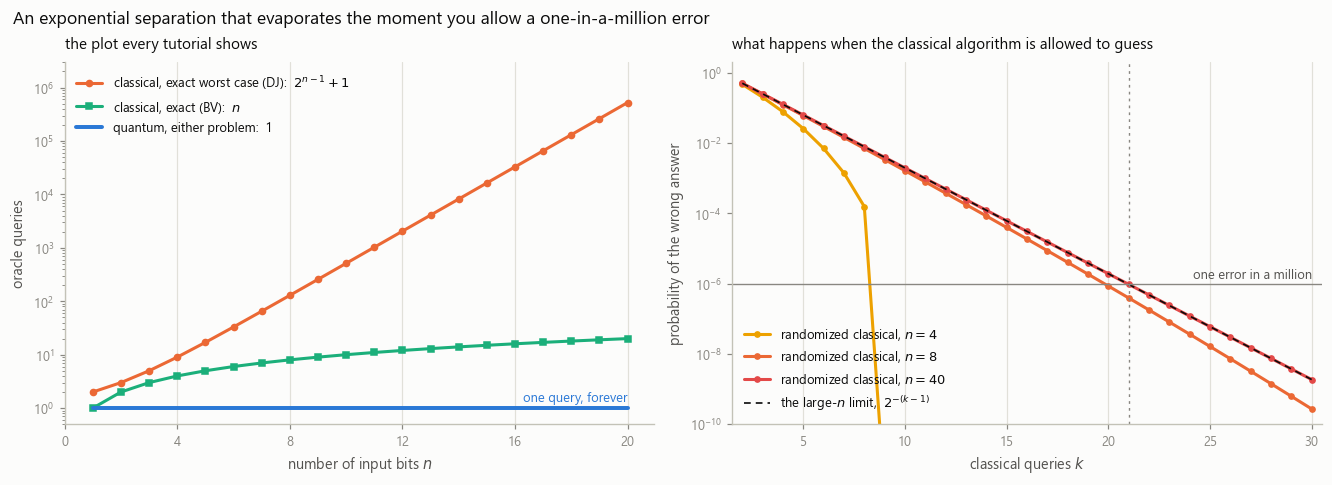

    n  exact classical    k for error < 1e-6   quantum
    4                9                     9         1
    8              129                    20         1
   16            32769                    21         1
   40     549755813889                    21         1
  100 633825300114114700748351602689                    21         1


In [10]:
def fooled_prob(n, k):
    """Exactly 2 * C(N/2, k) / C(N, k): the chance k distinct random samples of a
    balanced function all return the same bit."""
    N = 2.0 ** n
    if k > N / 2:
        return 0.0
    p = 2.0
    for i in range(k):
        p *= (N / 2 - i) / (N - i)
    return p


ns = np.arange(1, 21)
classical_dj = 2 ** (ns - 1) + 1
classical_bv = ns.astype(float)

fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.3))

ax = axes[0]
ax.semilogy(ns, classical_dj, color=style.ORANGE, marker="o", ms=4,
            label="classical, exact worst case (DJ):  $2^{n-1}+1$")
ax.semilogy(ns, classical_bv, color=style.AQUA, marker="s", ms=4,
            label="classical, exact (BV):  $n$")
ax.semilogy(ns, np.ones_like(ns), color=style.BLUE, lw=2.6,
            label="quantum, either problem:  1")
ax.set_xlabel("number of input bits $n$")
ax.set_ylabel("oracle queries")
ax.set_xticks(range(0, 21, 4))
ax.set_ylim(0.5, 3e6)
ax.grid(axis="both")
ax.legend(loc="upper left")
ax.set_title("the plot every tutorial shows", loc="left", fontsize=10)
ax.text(20, 1.35, "one query, forever", ha="right", fontsize=8.5,
        color=style.BLUE)

ax = axes[1]
ks = np.arange(2, 31)
for n, col in [(4, style.YELLOW), (8, style.ORANGE), (40, style.RED)]:
    ax.semilogy(ks, [max(fooled_prob(n, k), 1e-12) for k in ks], color=col,
                marker="o", ms=3.4, label=f"randomized classical, $n = {n}$")
ax.semilogy(ks, 2.0 ** (1 - ks), color=style.INK, lw=1.1, ls=(0, (4, 3)),
            label=r"the large-$n$ limit,  $2^{-(k-1)}$")
ax.axhline(1e-6, color=style.MUTED, lw=0.9)
ax.text(30, 1.4e-6, "one error in a million", ha="right", fontsize=8.5,
        color=style.INK_2)
ax.axvline(21, color=style.MUTED, lw=0.9, ls=(0, (2, 3)))
ax.set_xlabel("classical queries $k$")
ax.set_ylabel("probability of the wrong answer")
ax.set_ylim(1e-10, 2.0)
ax.set_xlim(1.5, 30.5)
ax.grid(axis="both")
ax.legend(loc="lower left")
ax.set_title("what happens when the classical algorithm is allowed to guess",
             loc="left", fontsize=10)

fig.suptitle("An exponential separation that evaporates the moment you allow "
             "a one-in-a-million error", x=0.005, ha="left", fontsize=11.5)
plt.show()

print(f"{'n':>5} {'exact classical':>16} {'k for error < 1e-6':>21} {'quantum':>9}")
for n in (4, 8, 16, 40, 100):
    k = next(k for k in range(1, 200) if fooled_prob(n, k) < 1e-6)
    print(f"{n:>5} {2**(n-1)+1:>16} {k:>21} {1:>9}")

The table is the punchline. At $n = 100$ the exact classical algorithm needs
$6\times10^{29}$ queries and the randomized one needs **22**. The quantum
algorithm needs 1. A factor of 22 is a real speedup and worth having; it is not
the factor of $10^{29}$ the left panel advertises.

Bernstein–Vazirani holds up rather better under the same scrutiny: $n$ classical
queries versus 1 is *tight* — randomization does not help, because you genuinely
have to extract $n$ bits and each classical query returns one bit. It is only a
linear speedup, but unlike Deutsch–Jozsa's it does not evaporate. (The
*recursive* Bernstein–Vazirani problem does give a superpolynomial separation
against randomized classical algorithms, which is the first place this line of
reasoning gets genuinely hard to beat.)

## Honest limits

**The promise is doing enormous work.** Figure 3's right panel showed it: off the
promise, $P(|000\rangle)$ is a continuous measure of imbalance and a single shot
tells you almost nothing. Real functions you would like to analyse are neither
constant nor balanced. There is no "approximate Deutsch–Jozsa" that degrades
gracefully — the algorithm's exactness *is* the promise.

**Randomization eats the speedup.** Figure 6. Two random queries already give you
the right answer 50% of the time with zero chance of a false "balanced"; twenty
give you six nines. Deutsch–Jozsa's exponential advantage exists against
deterministic exact classical algorithms and essentially vanishes against
randomized ones. Simon's problem and, later, Shor's are the ones that survive
this test.

**The oracle was handed to us as a unitary, which is a large thing to be handed.**
We wrote `xor_oracle` as an explicit $2^{n+1}\times2^{n+1}$ permutation matrix by
looping over every input and calling `f` on it. That loop *is* $2^n$ classical
queries. On real hardware you would compile $f$ into gates instead — but then the
circuit for $f$ has some depth $d$, and the honest accounting compares one
$d$-depth quantum circuit against a handful of classical evaluations of the same
$f$. For most $f$ the classical evaluation wins comfortably. **Query complexity
counts queries, not the cost of building the thing being queried**, and that gap
is where a lot of quantum-advantage claims quietly live.

**The oracle already contains the answer.** To *build* the Bernstein–Vazirani
oracle you must know $s$. The algorithm is a statement about how efficiently
information can be extracted from a box someone else built, not a way to discover
something nobody knows.

**Everything here is noiseless.** The final state is exactly $|s\rangle$ with
probability exactly 1, so one shot suffices. Give each gate a $10^{-3}$ error
rate and that becomes "the most likely outcome", the deterministic single-shot
readout becomes a majority vote over many shots, and the query count you were
bragging about goes up. B21 runs the same circuits through Qiskit, and C27 and
B26 are where noise gets taken seriously.

**The filmstrip draws something you can never see.** Every column of Figure 2 is
a full statevector — sixteen complex numbers we printed straight out of NumPy.
A real run gives you *one bitstring* from the last column and nothing whatsoever
from columns 2 and 3. The pictures in this repo show the mathematics; they do not
show an experiment. That is exactly why column 3 is so instructive and so
misleading at once: the information is visibly *there*, and it is visibly
unreadable.

**Amplitude bars stop scaling almost immediately.** Sixteen bars is already
crowded enough to need rotated labels. At $n = 10$ this figure is 1024 bars, and
Deutsch–Jozsa on 20 qubits — a completely routine size — cannot be drawn this way
at all. A07 confronts that wall directly.

## Checkpoint

In [11]:
# 1. Endianness: bit q of index i is (i >> q) & 1, and X on qubit 0 moves |0>
#    to index 1 in a register of any size.
for n in (2, 3, 4):
    v = np.zeros(2 ** n, dtype=complex); v[0] = 1.0
    assert int(np.argmax(np.abs(op_on(X, 0, n) @ v))) == 1
    for i in range(2 ** n):
        assert label(i, n) == "".join(str(bit(i, q)) for q in reversed(range(n)))

# 2. Both oracle forms are unitary, involutive, and agree via phase kickback.
for n in (2, 3):
    for trial in range(6):
        mask = rng.integers(0, 2, size=2 ** n)
        f = lambda x, m=mask: int(m[x])
        U, D = xor_oracle(f, n), phase_oracle(f, n)
        assert np.allclose(U.conj().T @ U, np.eye(2 ** (n + 1)))
        assert np.allclose(U @ U, np.eye(2 ** (n + 1)))
        assert np.allclose(D @ D, np.eye(2 ** n))
        assert np.allclose(np.diag(np.diag(D)), D)          # genuinely diagonal
        assert set(np.round(np.diag(D).real, 12)) <= {1.0, -1.0}
        psi = rng.normal(size=2 ** n) + 1j * rng.normal(size=2 ** n)
        psi /= np.linalg.norm(psi)
        assert np.allclose(U @ np.kron(MINUS, psi), np.kron(MINUS, D @ psi))

# 3. H^(x)n is unitary, involutive, and equals the Walsh-Hadamard matrix.
for n in range(1, 6):
    Hn = hadamard_all(n)
    assert np.allclose(Hn @ Hn, np.eye(2 ** n))
    assert np.allclose(Hn.conj().T @ Hn, np.eye(2 ** n))
    assert np.allclose(Hn, np.array([[(-1.0) ** parity(x & y) for x in range(2 ** n)]
                                     for y in range(2 ** n)]) / np.sqrt(2 ** n))

# 4. CONSTANT oracle -> all amplitude on |0...0>, and nowhere else.
for n in (2, 3, 4):
    for c in (0, 1):
        v = dj_stages(lambda x, c=c: c, n)[3]
        assert np.isclose(abs(v[0]), 1.0)
        assert np.allclose(v[1:], 0.0, atol=1e-12)
        assert np.isclose(np.abs(v[0]) ** 2, 1.0)

# 5. BALANCED oracle -> exactly zero amplitude on |0...0>, for ALL 70 balanced
#    functions on 3 bits, and for random balanced functions on 4 and 5 bits.
for m in balanced_masks:
    assert abs(dj_stages(f_from_mask(m), N_DJ)[3][0]) < 1e-12
for n in (4, 5):
    for trial in range(25):
        m = np.zeros(2 ** n, dtype=int)
        m[rng.permutation(2 ** n)[: 2 ** (n - 1)]] = 1
        assert abs(dj_stages(lambda x, m=m: int(m[x]), n)[3][0]) < 1e-12

# 6. The intermediate state really is unreadable: after the oracle every
#    probability is exactly 1/2^n, constant and balanced alike.
for f in (f_const, f_bal):
    p = np.abs(dj_stages(f, N_DJ)[2]) ** 2
    assert np.allclose(p, 1.0 / DIM_DJ)

# 7. The measured amplitude on |0...0> is the average sign, exactly.
for m in const_masks + balanced_masks[:20]:
    f = f_from_mask(m)
    want = sum((-1) ** f(x) for x in range(DIM_DJ)) / DIM_DJ
    assert np.isclose(dj_stages(f, N_DJ)[3][0].real, want)

# 8. BV recovers EVERY secret exactly, for n = 1..5, with probability 1.
for n in range(1, 6):
    for s in range(2 ** n):
        v = dj_stages(bv_oracle_f(s), n)[3]
        assert np.isclose(abs(v[s]), 1.0)
        assert np.allclose(np.delete(v, s), 0.0, atol=1e-12)
        assert int(np.argmax(np.abs(v) ** 2)) == s

# 9. The figure's 16 recovered secrets match the true ones bit for bit.
assert np.array_equal(recovered_all, secrets)
assert np.array_equal(true_img ^ rec_img, np.zeros_like(true_img))
assert np.allclose(prob_matrix, np.eye(N_IN), atol=1e-12)

# 10. Off the promise, P(|0..0>) is (k/4 - 1)^2 for k inputs mapping to 1 -- the
#     quantity the promise turns into a yes/no answer.
for m, k, p in zip(all_masks, n_ones, p0_all):
    assert np.isclose(p, (k / (DIM_DJ / 2) - 1.0) ** 2)

# 11. The randomized classical bound: never worse than 2^-(k-1), and monotone.
for n in (4, 8, 20):
    prev = 1.0
    for k in range(2, 15):
        pk = fooled_prob(n, k)
        assert pk <= 2.0 ** (1 - k) + 1e-15
        assert pk <= prev
        prev = pk

print("A09 checkpoint passed.")

A09 checkpoint passed.


---

**Next:** [A10 — Grover From Scratch](A10_Grover.ipynb). Deutsch–Jozsa got a
definite answer from one query because the interference was perfect: the wrong
outcomes cancelled to exactly zero. That only works because the promise made the
signs line up. Grover asks the harder question — *find the one input where
$f(x)=1$, with no promise at all* — and the answer is that a single round of
interference is not enough. You have to repeat it $\tfrac{\pi}{4}\sqrt{N}$ times,
and if you repeat it once too often the amplitude you were building starts coming
back down.